<a href="https://colab.research.google.com/github/Yaaxek/Validacion-de-modelos-y-metricas/blob/main/Desafios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Repaso

##Lectura de datos

1 - Para la construcción de un modelo de machine learning se necesitan datos. Como tarea inicial, realiza la lectura de la base de datos de diabetes y divide los datos en variables explicativas y variable objetivo (x e y). La variable objetivo es la columna que quieres clasificar, que contiene la información de si el paciente tiene o no diabetes. Las variables explicativas son todas las columnas excepto la de diabetes. La separación de los datos se puede hacer con la selección de columnas con pandas.

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
import pandas as pd

In [23]:
datos=pd.read_csv('/content/drive/MyDrive/Machine Learning/diabetes.csv')

In [24]:
datos

,glicemia,presion_sanguinea,grasa_subcutanea_triceps,insulina,imc,diabetes
0,66,23,94,28.1,0.167,0
1,40,35,168,43.1,2.288,1
2,50,32,88,31.0,0.248,1
3,70,45,543,30.5,0.158,1
4,60,23,846,30.1,0.398,1
...,...,...,...,...,...,...
389,88,44,510,43.3,0.222,1
390,88,39,110,36.5,1.057,1
391,58,26,16,28.4,0.766,0
392,76,48,180,32.9,0.171,0


In [25]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 394 entries, 0 to 393
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   glicemia                  394 non-null    int64  
 1   presion_sanguinea         394 non-null    int64  
 2   grasa_subcutanea_triceps  394 non-null    int64  
 3   insulina                  394 non-null    float64
 4   imc                       394 non-null    float64
 5   diabetes                  394 non-null    int64  
dtypes: float64(2), int64(4)
memory usage: 18.6 KB


In [26]:
X=datos.drop(columns='diabetes', axis=1)
y=datos['diabetes']

##Clasificacion de los modelos

2 - Una etapa muy importante en proyectos de clasificación es la validación de los modelos, para identificar si hay una generalización del modelo para datos nuevos. Realiza la división de los datos entre entrenamiento, validación y prueba. Utiliza el 5% de los datos para prueba y con el resto, deja el 25% para validación. En el momento de la separación, usa el parámetro stratify a partir de la variable objetivo para mantener la proporción de los datos.



In [27]:
from sklearn.model_selection import train_test_split

In [28]:
X,X_test,y,y_test=train_test_split(X,y,stratify=y,test_size=0.05,random_state=55)
X_train,X_val,y_train,y_val=train_test_split(X,y, stratify=y, random_state=55)

##Modelado de los datos

3 - La etapa de modelado de datos consiste en utilizar un algoritmo capaz de identificar patrones en los datos y clasificar los valores. A partir del modelo es posible extraer una tasa de acierto para entender su desempeño. Crea 2 modelos utilizando los algoritmos DecisionTreeClassifier y RandomForestClassifier y evalúa la precisión de entrenamiento y prueba, eligiendo el valor 3 para el parámetro max_depth del algoritmo DecisionTreeClassifier y el valor 2 para el max_depth del algoritmo RandomForestClassifier, para que los modelos no se especialicen demasiado en el patrón de los datos de entrenamiento.



In [29]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [30]:
tree=DecisionTreeClassifier(max_depth=3)
forest=RandomForestClassifier(max_depth=2)

In [31]:
tree.fit(X_train,y_train)
forest.fit(X_train,y_train)
print(f'La precision de entrenamiento del metodo del arbol es: {tree.score(X_train,y_train)}')
print(f'La precision de entrenamiento del metodo del bosque es: {forest.score(X_train,y_train)}')
print(f'La precision de validacion del metodo del arbol es: {tree.score(X_val,y_val)}')
print(f'La precision de validacion del metodo del bosque es: {forest.score(X_val,y_val)}')

La precision de entrenamiento del metodo del arbol es: 0.7535714285714286
La precision de entrenamiento del metodo del bosque es: 0.7571428571428571
La precision de validacion del metodo del arbol es: 0.6702127659574468
La precision de validacion del metodo del bosque es: 0.6914893617021277


##Matriz de confusion

4 - La tasa de acierto generalmente no proporciona información suficiente para entender el comportamiento del modelo. La matriz de confusión es una herramienta más completa, capaz de proporcionar los aciertos y errores del modelo para cada clase. Construye una matriz de confusión para cada uno de los modelos para evaluar el desempeño de la predicción. Para construir la matriz, usa el método predict para generar las predicciones de los valores y comparar con los valores reales de la base de datos.



In [32]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

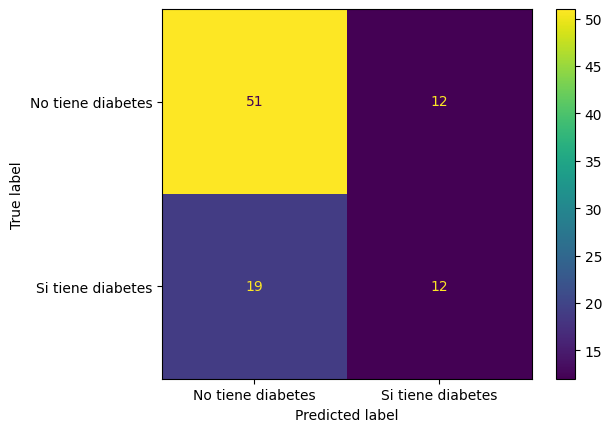

In [38]:
y_previsto_t=tree.predict(X_val)
ConfusionMatrixDisplay.from_predictions(y_val, y_previsto_t, display_labels=['No tiene diabetes','Si tiene diabetes']);

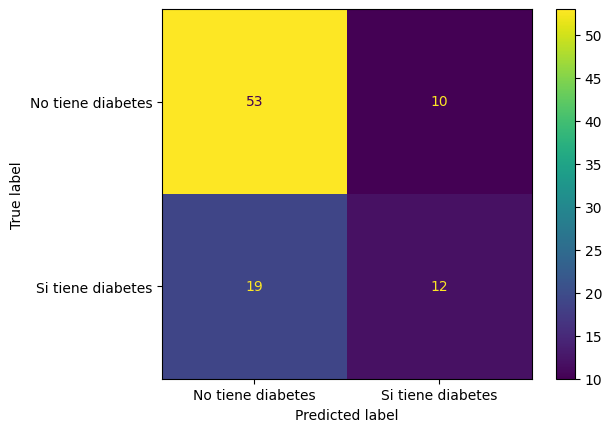

In [39]:
y_previsto_f=forest.predict(X_val)
ConfusionMatrixDisplay.from_predictions(y_val, y_previsto_f, display_labels=['No tiene diabetes','Si tiene diabetes']);

##Metricas de precision, recall, exactitud y f1-score

1 - Para una evaluación completa de un modelo de clasificación, podemos explorar métricas que evalúan la tasa de acierto general y también para cada clase de la variable objetivo de forma individual. Extrae las métricas de precisión, recall, precisión y F1-Score de los modelos de clasificación generados en el desafío de la clase 1. La biblioteca Scikit-Learn tiene funciones para calcular cada una de las métricas, solo necesitas importar y utilizar como parámetros los valores reales y previstos por el modelo.



In [35]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

In [42]:
prevision_t=tree.predict(X_val)
print(f'La precision del modelo del arbol es: {precision_score(y_val,y_previsto_t)}')
print(f'La exactitud del modelo del arbol es: {accuracy_score(y_val,y_previsto_t)}')
print(f'La sensibilidad del modelo del arbol es: {recall_score(y_val,y_previsto_t)}')
print(f'El f1-score del modelo del arbol es: {f1_score(y_val,y_previsto_t)}')

La precision del modelo del arbol es: 0.5
La exactitud del modelo del arbol es: 0.6702127659574468
La sensibilidad del modelo del arbol es: 0.3870967741935484
El f1-score del modelo del arbol es: 0.43636363636363634


In [43]:
prevision_f=forest.predict(X_val)
print(f'La precision del modelo del forest es: {precision_score(y_val,y_previsto_f)}')
print(f'La exactitud del modelo del forest es: {accuracy_score(y_val,y_previsto_f)}')
print(f'La sensibilidad del modelo del forest es: {recall_score(y_val,y_previsto_f)}')
print(f'El f1-score del modelo del forest es: {f1_score(y_val,y_previsto_f)}')

La precision del modelo del forest es: 0.5454545454545454
La exactitud del modelo del forest es: 0.6914893617021277
La sensibilidad del modelo del forest es: 0.3870967741935484
El f1-score del modelo del forest es: 0.4528301886792453


##Curva ROC y metrica AUC

2 - Además de métricas numéricas, se pueden explorar gráficos para evaluar el rendimiento de un modelo y comprender si puede diferenciar bien una clase de otra. Obtén la curva ROC y la métrica AUC de los modelos de clasificación generados en el desafío de la clase 1, comparando las curvas en el mismo gráfico. La curva ROC se puede generar usando el método RocCurveDisplay.from_predictions.



In [44]:
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score

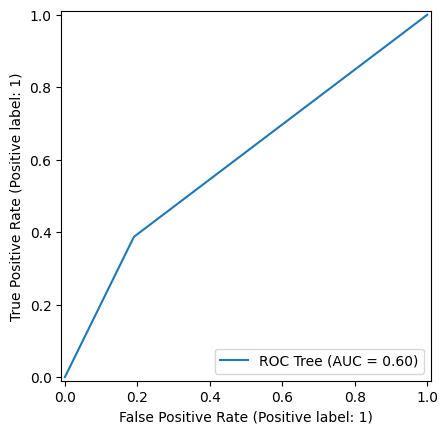

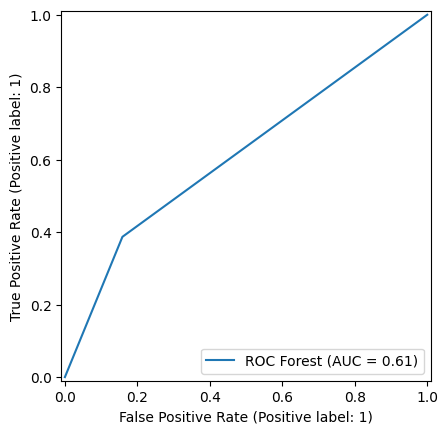

In [47]:
ROC_t=RocCurveDisplay.from_predictions(y_val,prevision_t, name='ROC Tree');
ROC_f=RocCurveDisplay.from_predictions(y_val,prevision_f, name='ROC Forest');

In [48]:
print(f'El area bajo la curva del modelo del arbol es: {roc_auc_score(y_val,prevision_t)}')
print(f'El area bajo la curva del modelo del forest es: {roc_auc_score(y_val,prevision_f)}')

El area bajo la curva del modelo del arbol es: 0.5983102918586789
El area bajo la curva del modelo del forest es: 0.6141833077316949


##Curva de precision vs recall y metrica AP

3 - Además de la curva ROC, la curva de precisión x recall se puede usar para evaluar el rendimiento de modelos, siendo más interesante para datos desbalanceados. Obtén la curva de precisión x recall y la métrica AP de los modelos de clasificación generados en el desafío de la clase 1, comparando las curvas en el mismo gráfico. La curva de precisión x recall se puede generar usando el método PrecisionRecallDisplay.from_predictions.



In [49]:
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import average_precision_score

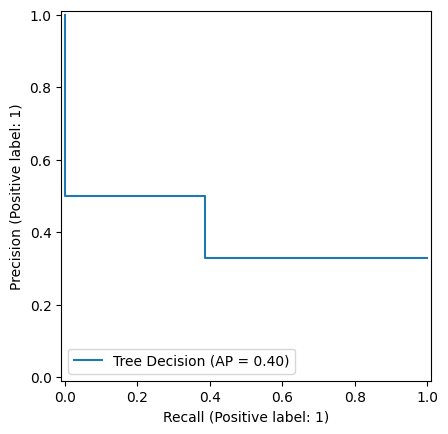

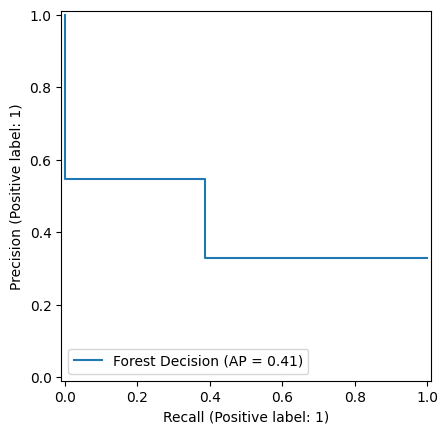

In [50]:
PXR_t=PrecisionRecallDisplay.from_predictions(y_val,prevision_t, name='Tree Decision');
PXR_f=PrecisionRecallDisplay.from_predictions(y_val,prevision_f, name='Forest Decision');

In [53]:
print(f'El score promedio de precision vs recall del modelo del arbol es: {average_precision_score(y_val,prevision_t)}')
print(f'El score promedio de precision vs recall del modelo del forest es: {average_precision_score(y_val,prevision_f)}')

El score promedio de precision vs recall del modelo del arbol es: 0.39567604667124223
El score promedio de precision vs recall del modelo del forest es: 0.4132713545891308


##Informe de las metricas

4 - Un resumen de las principales métricas de clasificación puede ser muy útil para resumir la información y generar insights de forma rápida. Genera los informes de métricas de los modelos de clasificación construidos en el desafío de la clase 1. El informe de métricas se puede generar a partir de la función classification_report de la biblioteca Scikit-Learn.



In [54]:
from sklearn.metrics import classification_report

In [59]:
print(f'Decision Tree:\n{classification_report(y_val,prevision_t)}')
print('\n*************************************************************\n*************************************************************')
print(f'Random Forest:\n{classification_report(y_val,prevision_f)}')

Decision Tree:
              precision    recall  f1-score   support

           0       0.73      0.81      0.77        63
           1       0.50      0.39      0.44        31

    accuracy                           0.67        94
   macro avg       0.61      0.60      0.60        94
weighted avg       0.65      0.67      0.66        94


*************************************************************
*************************************************************
Random Forest:
              precision    recall  f1-score   support

           0       0.74      0.84      0.79        63
           1       0.55      0.39      0.45        31

    accuracy                           0.69        94
   macro avg       0.64      0.61      0.62        94
weighted avg       0.67      0.69      0.68        94



##Intervalo de confianza

1 - En el proceso de validación cruzada, se generan diferentes modelos para cada división realizada en los datos y, en consecuencia, diferentes valores de métricas de evaluación. Para encontrar un resultado promedio de las métricas, se puede construir un intervalo de confianza a partir de la media y la desviación estándar de las métricas. Crea una función para calcular el intervalo de confianza de los resultados de una validación cruzada con 2 desviaciones estándar. La función necesita 2 parámetros: uno para recibir una lista con los resultados de las métricas de la validación cruzada y otro para recibir el nombre del algoritmo. Para generar el intervalo de confianza, extrae la media de los resultados de la lista y la desviación estándar. El intervalo de confianza debe ser presentado en un print con el valor mínimo siendo la media restada de 2 desviaciones estándar y el valor máximo siendo la media sumada de 2 desviaciones estándar. Ejemplo de retorno de la función:



Intervalo de confianza ("nombre del modelo"): ["valor mínimo del intervalo", "valor máximo del intervalo"]



In [61]:
def intervalo_confianza(resultado,nombre_modelo):
  promedio=resultado.mean()
  desvio_estandar=resultado.std()
  print(f'Intervalo de confianza ({nombre_modelo}): [{promedio - 2*desvio_estandar}, {min(promedio + 2*desvio_estandar, 1)}]')

##KFold

2 - KFold es la estrategia más simple de validación cruzada, que permite la división aleatoria de los datos en k partes, siendo utilizada una parte para validación y el resto para entrenamiento del modelo. El proceso de creación de modelos se repite hasta que todas las partes son utilizadas como validación. Sabiendo esto, evalúa el desempeño de los modelos con un intervalo de confianza utilizando la validación cruzada con el método KFold, usando 10 partes, con el uso del parámetro n_splits y mezclando los datos antes de la separación con el parámetro shuffle. Usa el método cross_val_score que no retorna el tiempo de ejecución, solo las métricas.



In [62]:
from sklearn.model_selection import KFold,cross_val_score

In [63]:
tree=DecisionTreeClassifier(max_depth=3)
forest=RandomForestClassifier(max_depth=2)
kf=KFold(n_splits=10,shuffle=True, random_state=55)

resultados_t=cross_val_score(tree,X,y,cv=kf)
resultados_f=cross_val_score(forest,X,y,cv=kf)
intervalo_confianza(resultados_t,'Decision Tree')
intervalo_confianza(resultados_f,'Random Forest')

Intervalo de confianza (Decision Tree): [0.5684841326501371, 0.7791687834238317]
Intervalo de confianza (Random Forest): [0.5213714493281866, 0.8632658195196085]


##SKFold

3 - En el proceso de división de datos con el KFold aleatorio, puede ser que la proporción de cada categoría de la variable objetivo no se mantenga en cada una de las partes de los datos. Para mantener esa proporción en cada una de las partes, podemos utilizar el KFold estratificado, haciendo que el proceso de validación de datos sea mucho más consistente. Evalúa el desempeño de los modelos con un intervalo de confianza utilizando la validación cruzada (cross_val_score) con el método StratifiedKFold, usando el parámetro n_splits y mezclando los datos antes de la separación con el parámetro shuffle y evaluando la métrica F1-Score usando el parámetro scoring.



In [64]:
from sklearn.model_selection import StratifiedKFold

In [65]:
tree=DecisionTreeClassifier(max_depth=3)
forest=RandomForestClassifier(max_depth=2)
skf=StratifiedKFold(n_splits=10,shuffle=True, random_state=55)

resultados_t=cross_val_score(tree,X,y,cv=skf,scoring='f1')
resultados_f=cross_val_score(forest,X,y,cv=skf, scoring='f1')
intervalo_confianza(resultados_t,'Decision Tree')
intervalo_confianza(resultados_f,'Random Forest')

Intervalo de confianza (Decision Tree): [0.2745012670450996, 0.6197472726176277]
Intervalo de confianza (Random Forest): [-0.023439150604665282, 0.6525365317386597]


##LeaveOneOut

4 - En conjuntos de datos con pocos registros (pocas filas), las estrategias de separación de los datos para validación pueden hacer que quede poca información en los datos de entrenamiento, haciendo que el modelo no comprenda bien el patrón de los datos. El LeaveOneOut es una estrategia para sortear este problema, utilizando solo un registro como dato de validación. Evalúa el desempeño de los modelos utilizando la validación cruzada (cross_val_score) con el método LeaveOneOut.

El método LeaveOneOut generará un modelo para cada una de las filas de la base de datos, por lo tanto, la lista de resultados tendrá tasa de acierto solo de 0 o 1 para cada modelo. De esta forma, extrae solo la media del resultado con el método mean(), sin utilizar el intervalo de confianza.

In [66]:
from sklearn.model_selection import cross_val_score,LeaveOneOut

In [68]:
tree=DecisionTreeClassifier(max_depth=3)
forest=RandomForestClassifier(max_depth=2)
loo=LeaveOneOut()

resultados_t=cross_val_score(tree,X,y,cv=loo)
resultados_f=cross_val_score(forest,X,y,cv=loo)
print(f'La precisión media de Decision Tree es: {resultados_t.mean()}')
print(f'La precisión media de Random Forest es:{resultados_f.mean()}')

La precisión media de Decision Tree es: 0.6256684491978609
La precisión media de Random Forest es:0.7112299465240641
